In [49]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [50]:
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

In [69]:
df = pd.read_csv("df_merged.csv", encoding="cp949")
df.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,OrderYear,OrderMonth,OrderDay,OrderHour,...,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax,Gender,Age,FamilyCount,MemberYN,AgeGroup
0,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M17-S0530-1024,33310,2023-01-07 06:24:00,2023,1,6,17,...,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0,여성,26,2,Y,20
1,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M21-S0540-1082,3780,2023-01-07 06:24:00,2023,1,6,17,...,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0,여성,26,2,Y,20
2,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M15-S0140-1311,22520,2023-01-07 06:24:00,2023,1,6,17,...,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0,여성,26,2,Y,20
3,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M12-S0350-1035,21630,2023-01-07 06:24:00,2023,1,6,17,...,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0,여성,26,2,Y,20
4,U10001,U10001-O2023-1003,2023-01-13 16:50:14,L4-M12-S0640-1057,11700,2023-01-14 06:28:00,2023,1,13,16,...,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0,여성,26,2,Y,20


In [70]:
df = df.dropna()

In [71]:
df.isnull().sum()

idUser              0
idOrder             0
OrderDT             0
ItemCode            0
Price               0
DeliveryDT          0
OrderYear           0
OrderMonth          0
OrderDay            0
OrderHour           0
OrderMinute         0
OrderWeekday        0
DeliveryYear        0
DeliveryMonth       0
DeliveryDay         0
DeliveryHour        0
DeliveryMinute      0
DeliveryWeekday     0
DeliveryDeadline    0
IsLate              0
ItemLargeCode       0
ItemLargeName       0
ItemMiddleCode      0
ItemMiddleName      0
ItemSmallCode       0
ItemSmallName       0
ItemName            0
PriceMin            0
PriceMax            0
Gender              0
Age                 0
FamilyCount         0
MemberYN            0
AgeGroup            0
dtype: int64

In [54]:
df.columns

Index(['idUser', 'idOrder', 'OrderDT', 'ItemCode', 'Price', 'DeliveryDT',
       'OrderYear', 'OrderMonth', 'OrderDay', 'OrderHour', 'OrderMinute',
       'OrderWeekday', 'DeliveryYear', 'DeliveryMonth', 'DeliveryDay',
       'DeliveryHour', 'DeliveryMinute', 'DeliveryWeekday', 'DeliveryDeadline',
       'IsLate', 'ItemLargeCode', 'ItemLargeName', 'ItemMiddleCode',
       'ItemMiddleName', 'ItemSmallCode', 'ItemSmallName', 'ItemName',
       'PriceMin', 'PriceMax', 'Gender', 'Age', 'FamilyCount', 'MemberYN',
       'AgeGroup'],
      dtype='object')

In [68]:
df.shape

(854101, 35)

In [55]:
# 1. 주차(year_week) 컬럼 생성
df['OrderDT'] = pd.to_datetime(df['OrderDT'])
df['year_week'] = df['OrderDT'].dt.isocalendar().year.astype(str) + '-W' + df['OrderDT'].dt.isocalendar().week.astype(str).str.zfill(2)

# 2. 숫자형 타입 변환
for col in ['OrderHour', 'OrderMonth', 'Price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. 주문 단위 객단가 계산 (주문별 총 금액)
order_total = df.groupby(['idUser', 'year_week', 'idOrder'])['Price'].sum().reset_index()
order_total.rename(columns={'Price': 'order_total'}, inplace=True)

# 4. 고객 × 주차 단위 객단가 평균 (타겟변수)
weekly_target = order_total.groupby(['idUser', 'year_week']).agg(
    weekly_avg_order_value=('order_total', 'mean')
).reset_index()

# 5. 숫자형 피처 집계
weekly_numeric = df.groupby(['idUser', 'year_week']).agg(
    OrderMonth=('OrderMonth', 'first'),
    avg_OrderHour=('OrderHour', 'mean'),
    category_count=('ItemLargeName', 'nunique'),
).reset_index()

# 6. 문자형 피처 별도 집계
weekly_cat = df.groupby(['idUser', 'year_week']).agg(
    top_category=('ItemLargeName', lambda x: x.mode().iloc[0]),
    Gender=('Gender', 'first'),
    Age=('Age', 'first'),
    FamilyCount=('FamilyCount', 'first'),
    MemberYN=('MemberYN', 'first')
).reset_index()

# 7. 전체 병합
df_weekly = weekly_target.merge(weekly_numeric, on=['idUser', 'year_week']).merge(weekly_cat, on=['idUser', 'year_week'])

print(f"데이터셋 shape: {df_weekly.shape}")
print(f"고객 수: {df_weekly['idUser'].nunique()}")
print(f"주차 수: {df_weekly['year_week'].nunique()}")
print(f"\nNaN 확인:")
print(df_weekly.isnull().sum())
print(f"\n컬럼: {df_weekly.columns.tolist()}")
df_weekly.head(10)

데이터셋 shape: (157948, 11)
고객 수: 3000
주차 수: 157

NaN 확인:
idUser                    0
year_week                 0
weekly_avg_order_value    0
OrderMonth                0
avg_OrderHour             0
category_count            0
top_category              0
Gender                    0
Age                       0
FamilyCount               0
MemberYN                  0
dtype: int64

컬럼: ['idUser', 'year_week', 'weekly_avg_order_value', 'OrderMonth', 'avg_OrderHour', 'category_count', 'top_category', 'Gender', 'Age', 'FamilyCount', 'MemberYN']


,idUser,year_week,weekly_avg_order_value,OrderMonth,avg_OrderHour,category_count,top_category,Gender,Age,FamilyCount,MemberYN
0,U10001,2023-W01,81240.0,1,17.000000,2,가공식품,여성,26,2,Y
1,U10001,2023-W02,60350.0,1,16.000000,2,가공식품,여성,26,2,Y
2,U10001,2023-W03,66370.0,1,20.000000,3,신선식품,여성,26,2,Y
3,U10001,2023-W04,142840.0,1,21.000000,2,가공식품,여성,26,2,Y
4,U10001,2023-W05,44560.0,2,16.000000,1,가공식품,여성,26,2,Y
5,U10001,2023-W06,62650.0,2,0.000000,1,신선식품,여성,26,2,Y
6,U10001,2023-W08,110870.0,2,13.500000,3,가공식품,여성,26,2,Y
7,U10001,2023-W09,55820.0,2,13.333333,2,신선식품,여성,26,2,Y
8,U10001,2023-W10,75070.0,3,23.000000,2,신선식품,여성,26,2,Y
9,U10001,2023-W13,74120.0,3,19.000000,3,가공식품,여성,26,2,Y


In [64]:
# === 모델링 준비 ===

# 1. 범주형 변수 인코딩
df_model = df_weekly.drop(columns=['idUser', 'year_week'])
df_model = pd.get_dummies(df_model, columns=['top_category', 'Gender', 'MemberYN'], drop_first=True , dtype=int) 

# 2. X, y 분리
y = df_model['weekly_avg_order_value']
X = df_model.drop(columns=['weekly_avg_order_value'])

print(f"X shape: {X.shape}")
print(f"피처 목록: {X.columns.tolist()}")
X.head()

X shape: (157948, 10)
피처 목록: ['OrderMonth', 'avg_OrderHour', 'category_count', 'Age', 'FamilyCount', 'top_category_생수', 'top_category_신선식품', 'top_category_음료', 'Gender_여성', 'MemberYN_Y']


,OrderMonth,avg_OrderHour,category_count,Age,FamilyCount,top_category_생수,top_category_신선식품,top_category_음료,Gender_여성,MemberYN_Y
0,1,17.0,2,26,2,0,0,0,1,1
1,1,16.0,2,26,2,0,0,0,1,1
2,1,20.0,3,26,2,0,1,0,1,1
3,1,21.0,2,26,2,0,0,0,1,1
4,2,16.0,1,26,2,0,0,0,1,1


In [65]:
# === 선형회귀 모델 ===

# 1. Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1234)

# 2. 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. 선형회귀 학습
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# 4. 예측 및 평가
y_pred = lr.predict(X_test_scaled)
print("=== 선형회귀 성능 ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):,.0f}원")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}원")

=== 선형회귀 성능 ===
R² Score: 0.0864
MAE: 26,296원
RMSE: 33,140원


=== 선형회귀 변수 중요도 (표준화 회귀계수) ===
               변수    회귀계수(표준화)          절대값
   category_count 10060.964434 10060.964434
  top_category_생수 -1026.637609  1026.637609
top_category_신선식품  -725.620991   725.620991
  top_category_음료  -674.445347   674.445347
    avg_OrderHour   156.855644   156.855644
       OrderMonth   133.032717   133.032717
              Age  -119.908371   119.908371
      FamilyCount    67.223815    67.223815
        Gender_여성    56.327627    56.327627
       MemberYN_Y     3.164752     3.164752


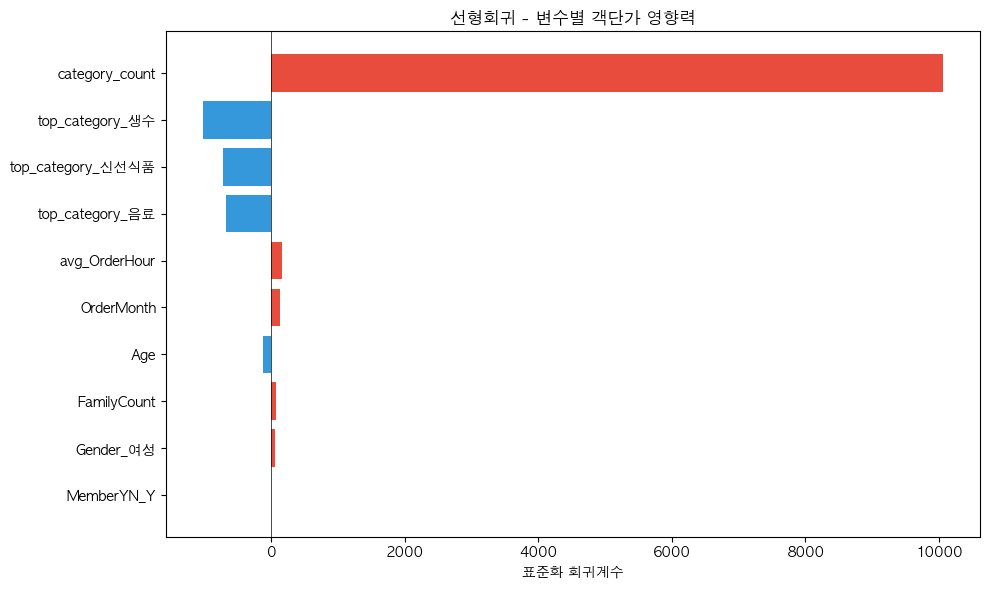

In [66]:
# === 회귀계수 기반 변수 중요도 ===

# 표준화된 회귀계수 → 절대값이 클수록 영향력 큼
coef_df = pd.DataFrame({
    '변수': X.columns,
    '회귀계수(표준화)': lr.coef_
})
coef_df['절대값'] = coef_df['회귀계수(표준화)'].abs()
coef_df = coef_df.sort_values('절대값', ascending=False).reset_index(drop=True)

print("=== 선형회귀 변수 중요도 (표준화 회귀계수) ===")
print(coef_df.to_string(index=False))

# 시각화
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in coef_df['회귀계수(표준화)']]
plt.barh(range(len(coef_df)), coef_df['회귀계수(표준화)'], color=colors)
plt.yticks(range(len(coef_df)), coef_df['변수'])
plt.xlabel('표준화 회귀계수')
plt.title('선형회귀 - 변수별 객단가 영향력')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [67]:
# === OLS 통계 검정 (p-value 확인) ===

X_ols = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train, X_ols).fit()

# 결과 요약
ols_summary = pd.DataFrame({
    '변수': ['상수'] + X.columns.tolist(),
    '회귀계수': ols_model.params,
    'p-value': ols_model.pvalues,
    '유의여부': ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '' for p in ols_model.pvalues]
})
print("=== OLS 통계 검정 결과 ===")
print(f"R² = {ols_model.rsquared:.4f}, Adj R² = {ols_model.rsquared_adj:.4f}")
print()
print(ols_summary.to_string(index=False))
print("\n* p<0.05, ** p<0.01, *** p<0.001")

=== OLS 통계 검정 결과 ===
R² = 0.0878, Adj R² = 0.0877

               변수         회귀계수      p-value 유의여부
               상수 76875.607436 0.000000e+00  ***
       OrderMonth   133.032717 1.787906e-01     
    avg_OrderHour   156.855644 1.129250e-01     
   category_count 10060.964434 0.000000e+00  ***
              Age  -119.908371 2.281562e-01     
      FamilyCount    67.223815 5.042131e-01     
  top_category_생수 -1026.637609 3.327753e-25  ***
top_category_신선식품  -725.620991 2.770504e-13  ***
  top_category_음료  -674.445347 9.603743e-12  ***
        Gender_여성    56.327627 5.910231e-01     
       MemberYN_Y     3.164752 9.755002e-01     

* p<0.05, ** p<0.01, *** p<0.001


In [60]:
# === RandomForest + GridSearchCV ===

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"최적 파라미터: {rf_grid.best_params_}")
print(f"최적 CV R²: {rf_grid.best_score_:.4f}")

y_pred_rf = rf_grid.predict(X_test)
print(f"\n=== RandomForest 테스트 성능 ===")
print(f"R² Score: {r2_score(y_test, y_pred_rf):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):,.0f}원")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):,.0f}원")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
최적 파라미터: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 200}
최적 CV R²: 0.1068

=== RandomForest 테스트 성능 ===
R² Score: 0.1052
MAE: 25,990원
RMSE: 32,797원


In [61]:
# === XGBoost + GridSearchCV ===

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid=xgb_params,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print(f"최적 파라미터: {xgb_grid.best_params_}")
print(f"최적 CV R²: {xgb_grid.best_score_:.4f}")

y_pred_xgb = xgb_grid.predict(X_test)
print(f"\n=== XGBoost 테스트 성능 ===")
print(f"R² Score: {r2_score(y_test, y_pred_xgb):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):,.0f}원")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):,.0f}원")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
최적 파라미터: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
최적 CV R²: 0.1071

=== XGBoost 테스트 성능 ===
R² Score: 0.1054
MAE: 25,985원
RMSE: 32,793원


In [62]:
# === LightGBM + GridSearchCV ===

lgbm_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [15, 31],
    'subsample': [0.8, 1.0]
}

lgbm_grid = GridSearchCV(
    LGBMRegressor(random_state=42, verbosity=-1),
    param_grid=lgbm_params,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

lgbm_grid.fit(X_train, y_train)

print(f"최적 파라미터: {lgbm_grid.best_params_}")
print(f"최적 CV R²: {lgbm_grid.best_score_:.4f}")

y_pred_lgbm = lgbm_grid.predict(X_test)
print(f"\n=== LightGBM 테스트 성능 ===")
print(f"R² Score: {r2_score(y_test, y_pred_lgbm):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lgbm):,.0f}원")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lgbm)):,.0f}원")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
최적 파라미터: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 15, 'subsample': 0.8}
최적 CV R²: 0.1071

=== LightGBM 테스트 성능 ===
R² Score: 0.1055
MAE: 25,984원
RMSE: 32,791원


=== 모델 성능 비교 ===
          모델       R²          MAE         RMSE
        선형회귀 0.086387 26295.528006 33140.044626
RandomForest 0.105188 25989.687288 32797.264706
     XGBoost 0.105448 25985.039624 32792.516308
    LightGBM 0.105532 25984.354466 32790.967512


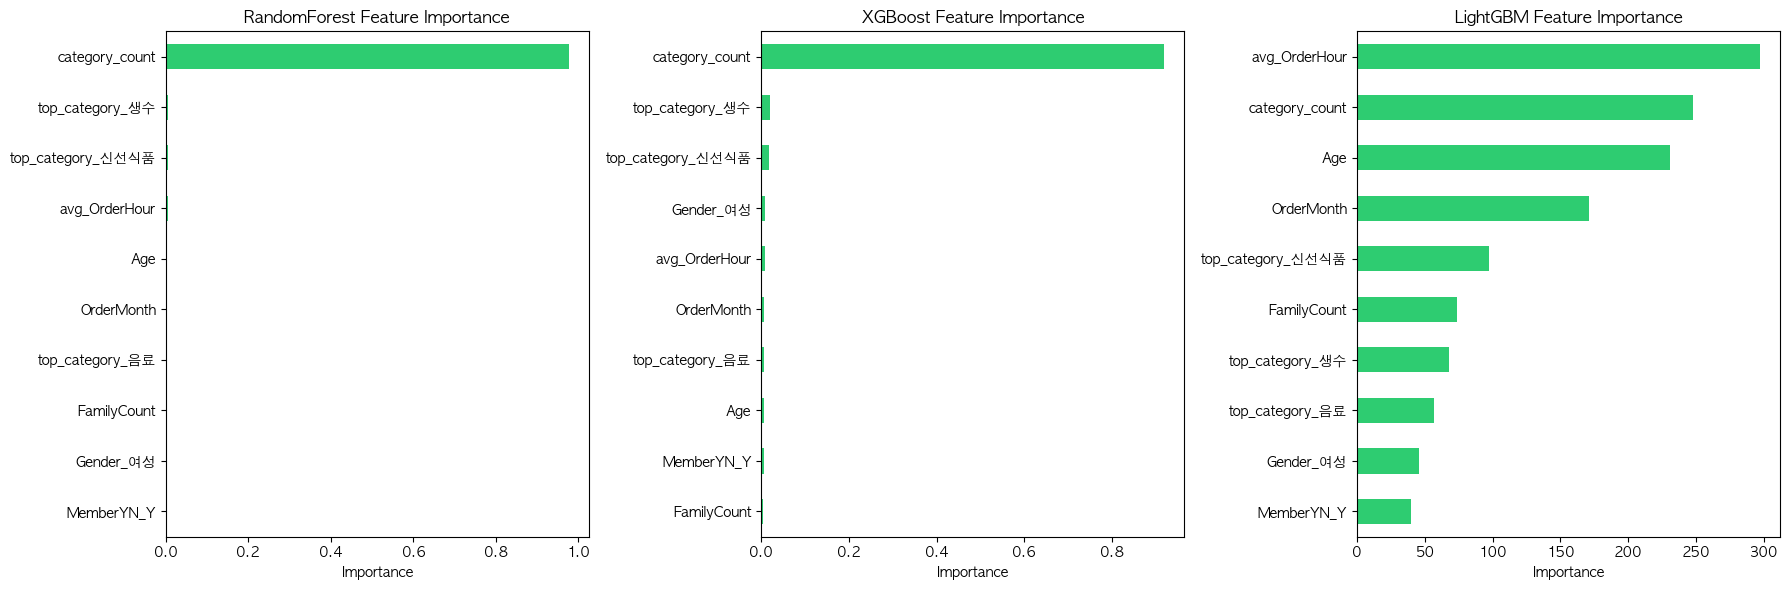

In [63]:
# === 모델 성능 비교 + Feature Importance ===

# 1. 성능 비교표
results = pd.DataFrame({
    '모델': ['선형회귀', 'RandomForest', 'XGBoost', 'LightGBM'],
    'R²': [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_lgbm)
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb),
        mean_absolute_error(y_test, y_pred_lgbm)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
    ]
})
print("=== 모델 성능 비교 ===")
print(results.to_string(index=False))

# 2. 트리 모델 Feature Importance 비교
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, model, name in zip(axes,
    [rf_grid.best_estimator_, xgb_grid.best_estimator_, lgbm_grid.best_estimator_],
    ['RandomForest', 'XGBoost', 'LightGBM']):
    
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
    imp.plot(kind='barh', ax=ax, color='#2ecc71')
    ax.set_title(f'{name} Feature Importance')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [72]:
# 주차(week) 컬럼 생성
df['OrderDT'] = pd.to_datetime(df['OrderDT'])
df['OrderWeek'] = df['OrderDT'].dt.isocalendar().week
df['OrderYearWeek'] = df['OrderYear'].astype(str) + '-W' + df['OrderWeek'].astype(str).str.zfill(2)

In [73]:
weekly_spend = df.groupby(['idUser', 'OrderYearWeek']).agg(
    target_weekly_spend = ('Price', 'sum')  # 주간 총 지출
).reset_index()

In [76]:
# 1. 문제 컬럼들 타입 확인
print(df.dtypes)

idUser                      object
idOrder                     object
OrderDT             datetime64[ns]
ItemCode                    object
Price                        int64
DeliveryDT                  object
OrderYear                    int64
OrderMonth                   int64
OrderDay                     int64
OrderHour                    int64
OrderMinute                  int64
OrderWeekday                object
DeliveryYear                 int64
DeliveryMonth                int64
DeliveryDay                  int64
DeliveryHour                 int64
DeliveryMinute               int64
DeliveryWeekday             object
DeliveryDeadline            object
IsLate                        bool
ItemLargeCode               object
ItemLargeName               object
ItemMiddleCode              object
ItemMiddleName              object
ItemSmallCode               object
ItemSmallName               object
ItemName                    object
PriceMin                   float64
PriceMax            

In [74]:
features = df.groupby(['idUser', 'OrderYearWeek']).agg(
    # 구매 행동
    order_count = ('idOrder', 'nunique'),          # 주문 횟수
    item_count = ('ItemCode', 'count'),            # 구매 아이템 수
    unique_items = ('ItemCode', 'nunique'),         # 고유 아이템 수
    avg_price = ('Price', 'mean'),                  # 평균 아이템 가격
    max_price = ('Price', 'max'),
    min_price = ('Price', 'min'),
    
    # 배송 관련
    late_ratio = ('IsLate', 'mean'),               # 지연 비율
    avg_delivery_deadline = ('DeliveryDeadline', 'mean'),
    
    # 시간 패턴
    avg_order_hour = ('OrderHour', 'mean'),        # 평균 주문 시간대
    most_common_weekday = ('OrderWeekday', lambda x: x.mode()[0]),
    
    # 카테고리 다양성
    category_diversity = ('ItemLargeCode', 'nunique'),
    
    # 고객 정보 (고정값이므로 first)
    gender = ('Gender', 'first'),
    age = ('Age', 'first'),
    family_count = ('FamilyCount', 'first'),
    member_yn = ('MemberYN', 'first'),
    age_group = ('AgeGroup', 'first'),
).reset_index()

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
# 유저별 시간순 정렬
features = features.sort_values(['idUser', 'OrderYearWeek'])

# lag 피처: 지난주 객단가
features['prev_week_spend'] = features.groupby('idUser')['target_weekly_spend'].shift(1)

# 최근 4주 평균 객단가
features['rolling_4w_avg_spend'] = (
    features.groupby('idUser')['target_weekly_spend']
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
)

# 누적 평균 객단가
features['cumulative_avg_spend'] = (
    features.groupby('idUser')['target_weekly_spend']
    .transform(lambda x: x.shift(1).expanding().mean())
)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 결측 제거 (첫 주차는 lag가 없으므로)
model_df = features.dropna(subset=['prev_week_spend'])

# 범주형 인코딩
model_df['gender'] = model_df['gender'].astype('category').cat.codes
model_df['member_yn'] = model_df['member_yn'].astype('category').cat.codes
model_df['age_group'] = model_df['age_group'].astype('category').cat.codes

# 피처 / 타겟 분리
drop_cols = ['idUser', 'OrderYearWeek', 'target_weekly_spend']
X = model_df.drop(columns=drop_cols)
y = model_df['target_weekly_spend']

# 시계열이므로 시간 기준 분할 권장
split_point = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

# 모델 학습
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
model.fit(X_train, y_train)

# 평가
pred = model.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, pred):.2f}")
print(f"R²:  {r2_score(y_test, pred):.4f}")
print(f"RMSE: {np.sqrt(((y_test - pred)**2).mean()):.2f}")

In [ ]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'][:15], importance['importance'][:15])
plt.title('Feature Importance - Top 15')
plt.show()